This kernel will implement classical image techniques and will hopefully serve as a useful primer to people who have never worked with image data before. Ultimately, we will develop a simple pipeline using `scipy` and `numpy` (and a little bit of `scikit-image`) that we can apply to the test images -- in fact, we won't even use the training images except to optimize parameters.

I'll keep updating this notebook to try and improve it - user Gabro Vecsei takes a similar approach and scores 0.22 in [this kernel](<https://www.kaggleusercontent.com/kf/2310019/eyJhbGciOiJkaXIiLCJlbmMiOiJBMTI4Q0JDLUhTMjU2In0..Ma3wLryNRISkouVuyqKoCw.2eSWCc_cAoTc-7a1u36Q2k2Xcs4RjuNwSVdhxBCitnuXjO1sXOBPqJxgmWZ4-1dvxWYxVMTmywbe5Rugk8ttemX_AdpWHZmNIWvWvQmM7oq4_PKAYtXsKC2QMWvVDttXFOb4DS1OS127tSATzdRVidTKnlVT_2XToZvWxe9rD0bGHty0mKEZINjvpnSS3nLcWwyfZ_ApZfTBw5ip37fDo7VLYacRPTbO6uegxMyR1xpYAIac2asMn5P96GfUY-GZiICbC42qEjuDEjbNKZU-a4AqgQbkR4l-NHH9beQXLd0zd59_bjD3iqJTJLqXOjTkzwia8u3caVJJdfEX0Wr_b0-6SRYAAor9WN6XcvM01eIu8PfDU29d-t0R8MxEAYDc07tmy6YfABi004jQZ5IEAk0IELfWR-xXffRT54xhf2bpAtShL3BjFfOnsg2JlW5Si54-xMtZZZfh-t9GJ_W7TfyVFT46OYDScAK91yDEQI_h1OuYNJ58P_SXpGT5kqKgRNF8vo2RJgaE6Md5-qccVMdW33AE_yfJSB5cg_znf-OCzT37716XJI3l0kvwI2dFn7rKpSB-zD3EfPw1mPhv1FagamsPdzgHzKf5gZNkwQLDFS5Q5jUXUGAnasO6SAprHw_3fGvtn7I_cVB-XNhCXw.MlBvmGemmW3Mndc6st9E5A/(https://www.kaggle.com/gaborvecsei/basic-pure-computer-vision-segmentation-lb-0-229>). My main intention here, though, is to help out people who are new to analyses, not to score highly.

In [1]:
import pathlib
import imageio
import numpy as np

training_paths = pathlib.Path('./input/stage1_train').glob('*/images/*.png')
training_sorted = sorted([x for x in training_paths])
im_path = training_sorted[45]
im = imageio.imread(str(im_path))

C:\Users\USER\AppData\Local\Temp\ipykernel_6100\2958902537.py:8: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  im = imageio.imread(str(im_path))


## Dealing with color

The images in this dataset can be in RGB, RGBA and grayscale format, based on the "modality" in which they are acquired. For color images, there is a third dimension which encodes the "channel" (e.g. Red, Green, Blue). To make things simpler for this first pass, we can coerce all these images into grayscale using the `rgb2gray` function from `scikit-image`.

In [3]:
print('Original image shape: {}'.format(im.shape))

from skimage.color import rgb2gray
im = im[:, :, :3]
im_gray = rgb2gray(im)
print('New image shape: {}'.format(im_gray.shape))

Original image shape: (520, 696, 4)
New image shape: (520, 696)


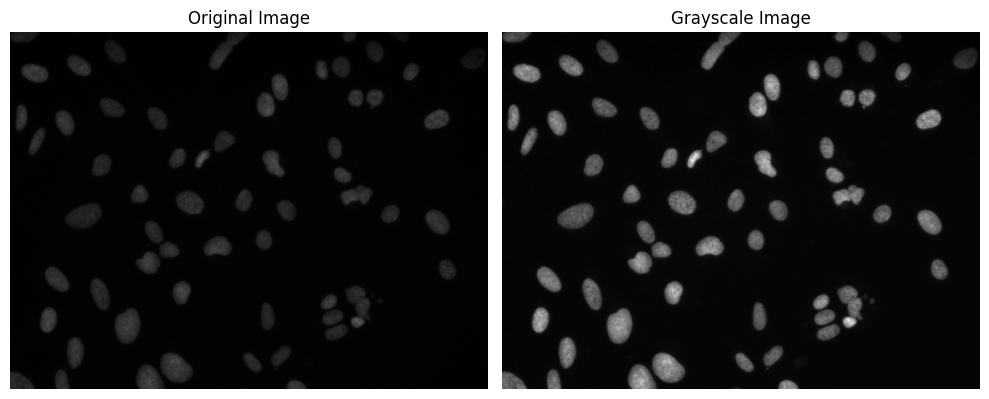

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(im)
plt.axis('off')
plt.title('Original Image')

plt.subplot(1, 2, 2)
plt.imshow(im_gray, cmap='gray')
plt.axis('off')
plt.title('Grayscale Image')

plt.tight_layout()
plt.show()

## Removing background

Perhaps the simplest approach for this problem is to assume that there are two classes in the image: objects of interest and the background. Under this assumption, we would expect the data to fall into a bimodal distribution of intensities. If we found the best separation value, we could "mask" out the background data, then simply count the objects we're left with.

The "dumbest" way we could find the threshold value would be to use a simple descriptive statistic, such as the mean or median. But there are other methods: the "Otsu" method is useful because it models the image as a bimodal distribution and finds the optimal separation value.

In [5]:
from skimage.filters import threshold_otsu
thresh_val = threshold_otsu(im_gray)
mask = np.where(im_gray > thresh_val, 1, 0)

if np.sum(mask==0) < np.sum(mask==1):
    mask = np.where(mask, 0, 1)

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
im_pixels = im_gray.flatten()
plt.hist(im_pixels, bins=50)
plt.vlines(thresh_val, 0, 100000, linestyle='--')
plt.ylim([0, 50000])
plt.title('Grayscale Histogram')

plt.subplot(1, 2, 2)
